In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu'   )

In [3]:
print(DEVICE)

cuda


In [4]:
import os
DATA_DIR = '../data/processed/'

X_train = np.load(DATA_DIR + 'X_train_scaled_cancer.npy')
X_val = np.load(DATA_DIR + 'X_val_scaled_cancer.npy')
X_test = np.load(DATA_DIR + 'X_test_scaled_cancer.npy')

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(type(X_train))

(341, 30)
(114, 30)
(114, 30)
<class 'numpy.ndarray'>


In [5]:
y_train = np.load(DATA_DIR + 'y_train_cancer.npy')
y_val = np.load(DATA_DIR + 'y_val_cancer.npy')
y_test = np.load(DATA_DIR + 'y_test_cancer.npy')

print(y_train.shape)
print(type(y_train))

(341,)
<class 'numpy.ndarray'>


In [6]:
X_train_t = torch.tensor(X_train, dtype = torch.float32)
X_test_t = torch.tensor(X_test, dtype = torch.float32)
X_val_t = torch.tensor(X_val, dtype = torch.float32)

print(X_train_t.shape)
print(X_val_t.shape)
print(X_test_t.shape)
print(type(X_train_t))

torch.Size([341, 30])
torch.Size([114, 30])
torch.Size([114, 30])
<class 'torch.Tensor'>


In [7]:
y_train_t = torch.tensor(y_train, dtype = torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype = torch.float32).unsqueeze(1)
y_val_t = torch.tensor(y_val, dtype = torch.float32).unsqueeze(1)

print(y_train_t.shape)
print(type(y_train_t))


torch.Size([341, 1])
<class 'torch.Tensor'>


In [8]:
class LogisticDataset(Dataset):
    def __init__(self, X,y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx] , self.y[idx]

In [9]:
training_dataset = LogisticDataset(X_train_t, y_train_t)
validation_dataset = LogisticDataset(X_val_t, y_val_t)
testing_dataset = LogisticDataset(X_test_t, y_test_t)



In [10]:
print(training_dataset[0])

(tensor([-1.5895, -1.3608, -1.5522, -1.2792,  0.5916, -0.4925, -0.7697, -0.8602,
        -0.4526,  1.1800, -1.1683, -0.9623, -1.0053, -0.9199,  0.2719, -0.4111,
        -0.4167, -0.6625, -0.5490,  0.0278, -1.4072, -1.1442, -1.3089, -1.0886,
         1.3998, -0.1951, -0.4599, -0.4268,  0.0891,  1.0829]), tensor([1.]))


In [11]:
len(training_dataset)

341

In [12]:
train_loader = DataLoader(training_dataset, batch_size= 32, shuffle = True, num_workers= 0)
val_loader = DataLoader(validation_dataset, batch_size= 32, shuffle = False, num_workers= 0)
test_loader = DataLoader(testing_dataset, batch_size= 32, shuffle = False, num_workers= 0)

In [13]:
class LogisticRegression(nn.Module):
    def __init__(self, D_in, D_out = 1):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(D_in, D_out)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))
        
            

In [14]:
D_in = X_train_t.shape[-1]

In [15]:
D_in

30

In [16]:
classifer_model = LogisticRegression(D_in)

In [17]:
classifer_model = classifer_model.to(DEVICE)
print(classifer_model)

LogisticRegression(
  (linear): Linear(in_features=30, out_features=1, bias=True)
)


In [18]:
classifer_model.linear.weight.data

tensor([[-0.0941,  0.0999,  0.1439, -0.0403, -0.1350, -0.1803,  0.0038, -0.0274,
          0.0109,  0.0800,  0.1597,  0.1451, -0.0303, -0.0209,  0.1707, -0.0789,
         -0.1290, -0.0294, -0.1068, -0.1475, -0.0703,  0.0257, -0.0930, -0.1320,
         -0.1142, -0.0458,  0.0845, -0.0482, -0.1469, -0.1782]],
       device='cuda:0')

In [19]:
criterion = nn.BCELoss()
LEARNING_RATE = 1e-3
optimizer = torch.optim.Adam(classifer_model.parameters(), lr = LEARNING_RATE)

In [20]:
N_EPOCHS = 50
train_losses= []
val_losses = []

for epoch in range(N_EPOCHS):
    classifer_model.train()
    epoch_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        predictions = classifer_model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss/len(train_loader)
    train_losses.append(avg_train_loss)

    classifer_model.eval()
    epoch_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            val_predictions = classifer_model(X_batch)
            val_loss = criterion(val_predictions, y_batch)
            epoch_val_loss += val_loss.item()

    avg_val_loss = epoch_val_loss/len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"for {epoch+1}/{N_EPOCHS} epoch: the training loss: {avg_train_loss:.4f} and validation loss: {avg_val_loss:.4f}")

for 1/50 epoch: the training loss: 0.4948 and validation loss: 0.4718
for 2/50 epoch: the training loss: 0.4569 and validation loss: 0.4361
for 3/50 epoch: the training loss: 0.4262 and validation loss: 0.4053
for 4/50 epoch: the training loss: 0.3947 and validation loss: 0.3787
for 5/50 epoch: the training loss: 0.3681 and validation loss: 0.3558
for 6/50 epoch: the training loss: 0.3450 and validation loss: 0.3359
for 7/50 epoch: the training loss: 0.3298 and validation loss: 0.3186
for 8/50 epoch: the training loss: 0.3125 and validation loss: 0.3030
for 9/50 epoch: the training loss: 0.2961 and validation loss: 0.2890
for 10/50 epoch: the training loss: 0.2850 and validation loss: 0.2767
for 11/50 epoch: the training loss: 0.2763 and validation loss: 0.2651
for 12/50 epoch: the training loss: 0.2630 and validation loss: 0.2548
for 13/50 epoch: the training loss: 0.2540 and validation loss: 0.2455
for 14/50 epoch: the training loss: 0.2461 and validation loss: 0.2372
for 15/50 epoch

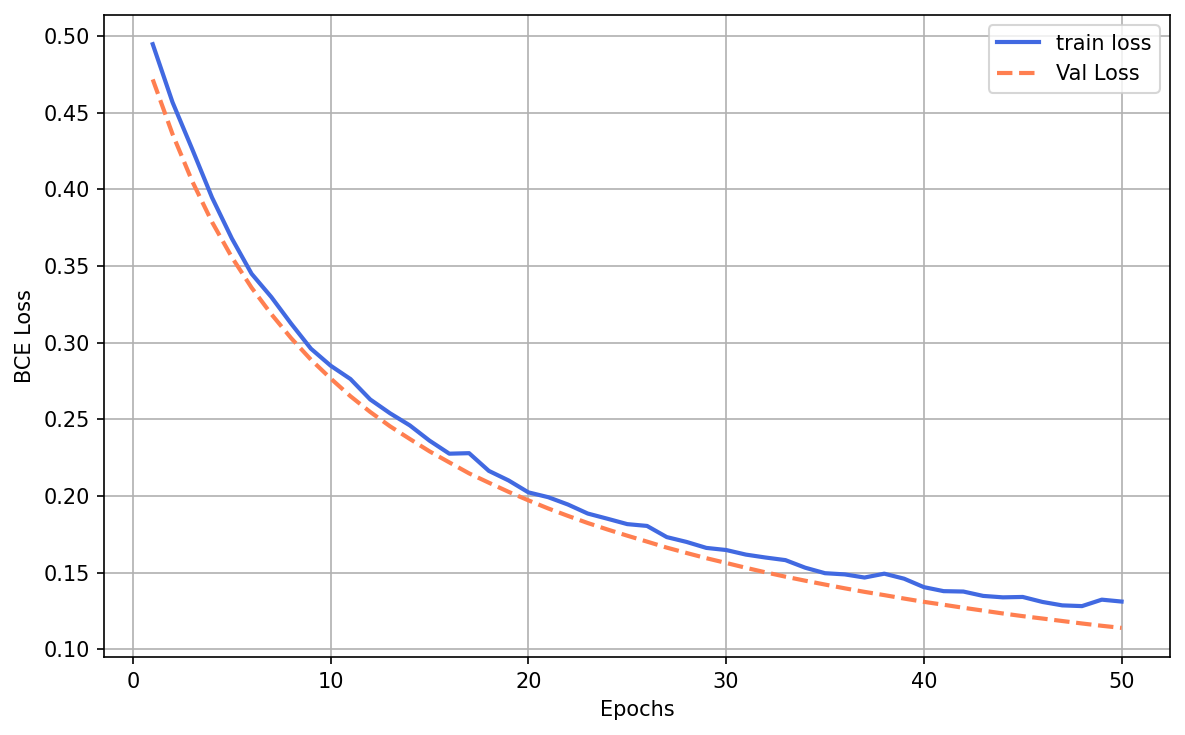

In [21]:
plt.figure(figsize=(8,5),dpi = 150)
epochs_range = range(1, N_EPOCHS + 1)
plt.plot(epochs_range, train_losses, linewidth = 2, color = 'royalblue', label = 'train loss')
plt.plot(epochs_range, val_losses, linewidth = 2, color = 'coral', ls='--', label = 'Val Loss')
plt.xlabel('Epochs')
plt.ylabel('BCE Loss')
plt.legend(loc = 1)
plt.grid()
plt.tight_layout()
plt.savefig('test_figue.png', dpi = 200)